### Missing Values Processing

In [1]:
import pandas as pd
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import matplotlib.pyplot as plt
import seaborn as sns 

After overviewing the data, we eliminate features that are filled with a single value since they do not provide useful information for models.

In [3]:
Data = pd.read_csv('../Data/FPD.csv')

constant_cols = [col for col in Data.columns if Data[col].nunique() == 1]
Data = Data.drop(columns=constant_cols)
print("Constant columns eliminated:", constant_cols)

Constant columns eliminated: ['feature_59', 'feature_67', 'feature_68', 'feature_69', 'feature_70']


next, we ignore ID wich is unique for each row and therefore, it also does not help the model at all. we also use imputation to fill NaN values

In [5]:
Data = Data.drop(columns=['ID'], errors='ignore')

for col in Data.columns:
    if Data[col].dtype == 'bool':
        Data[col] = Data[col].astype(int)


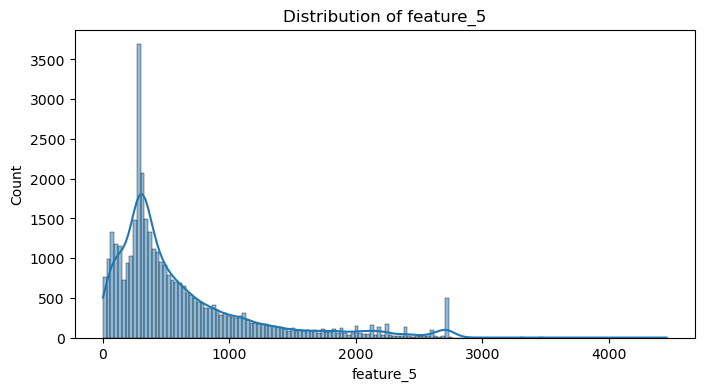

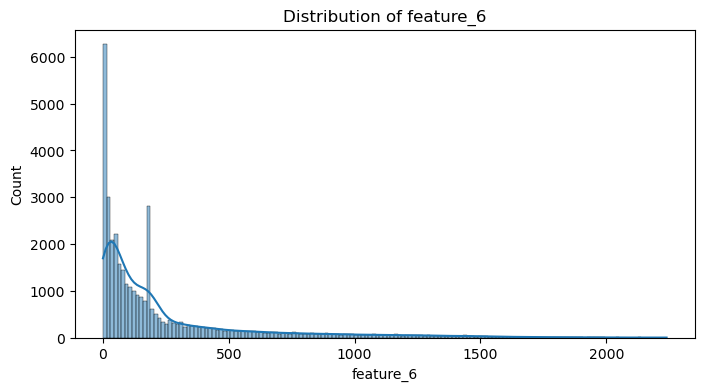

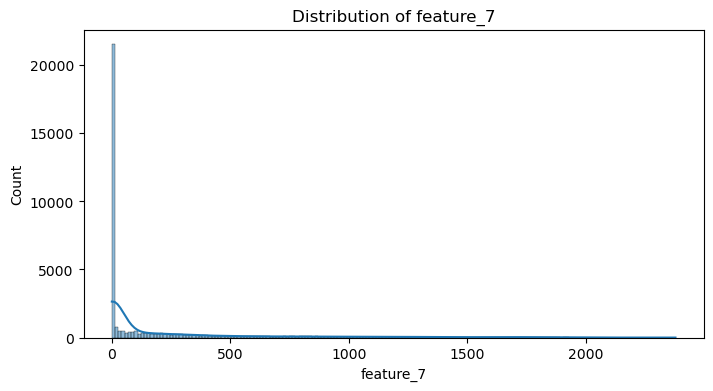

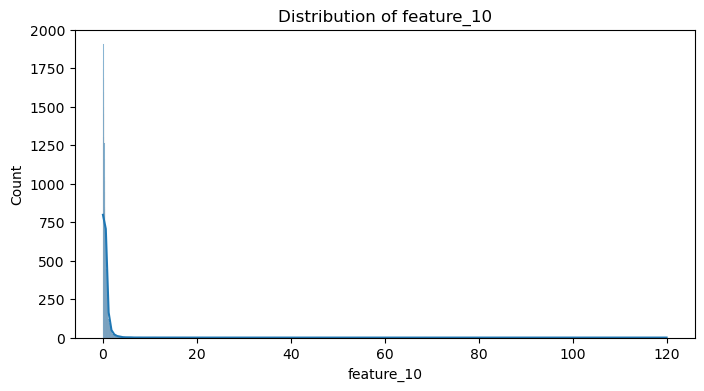

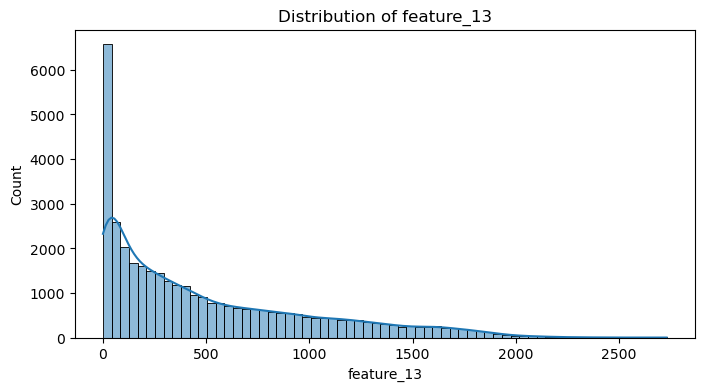

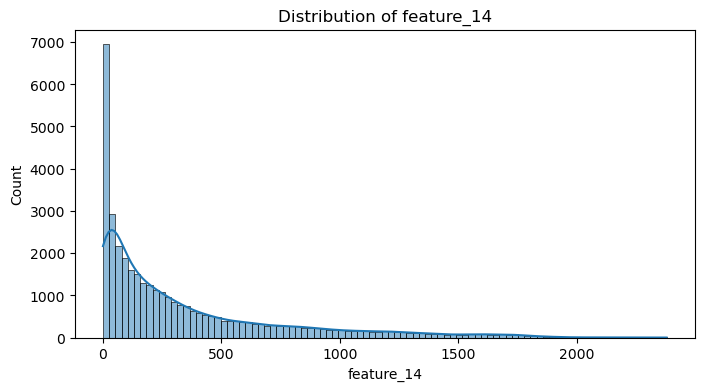

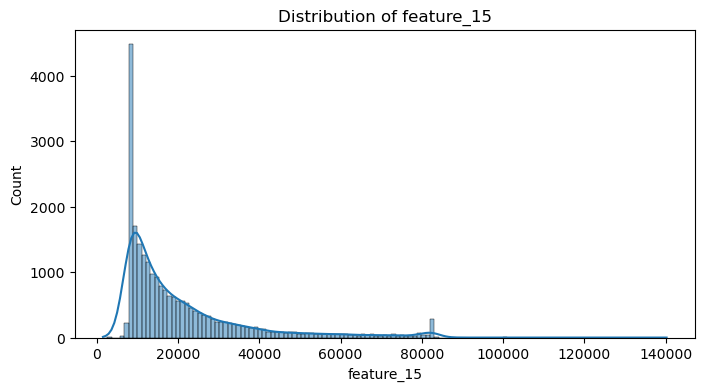

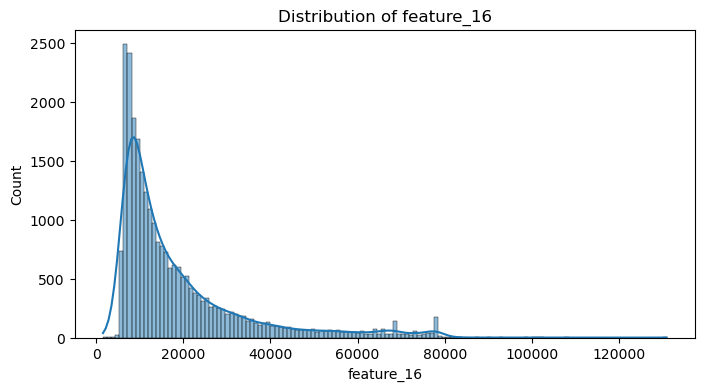

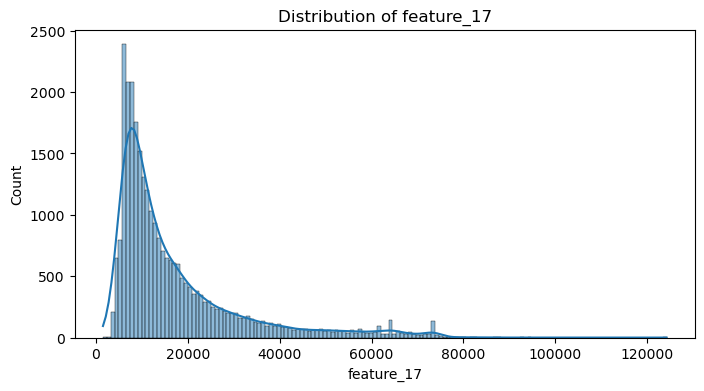

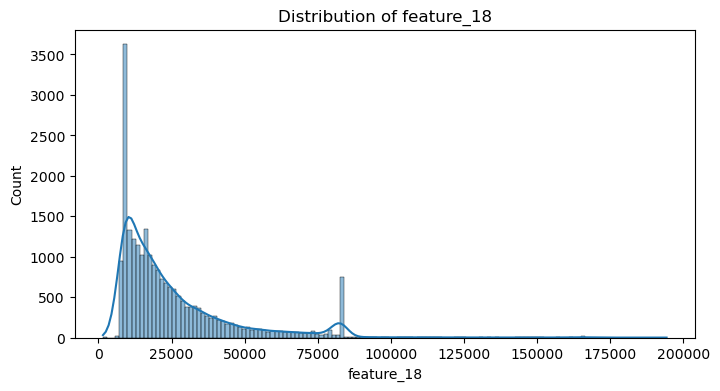

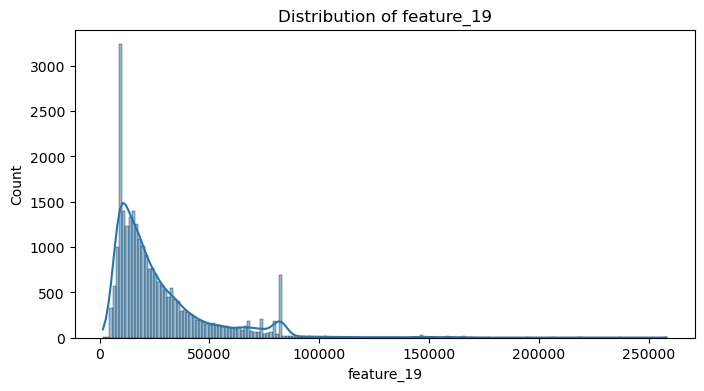

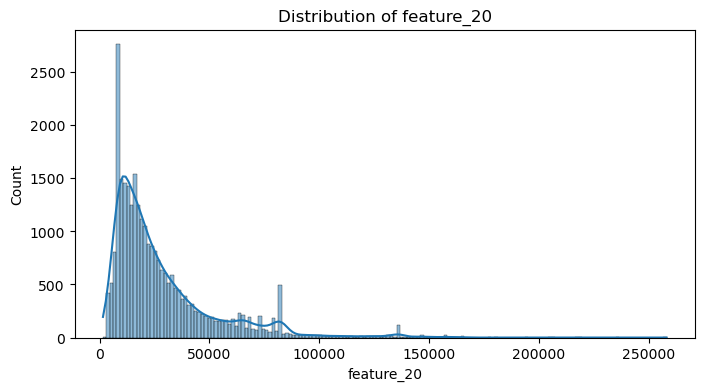

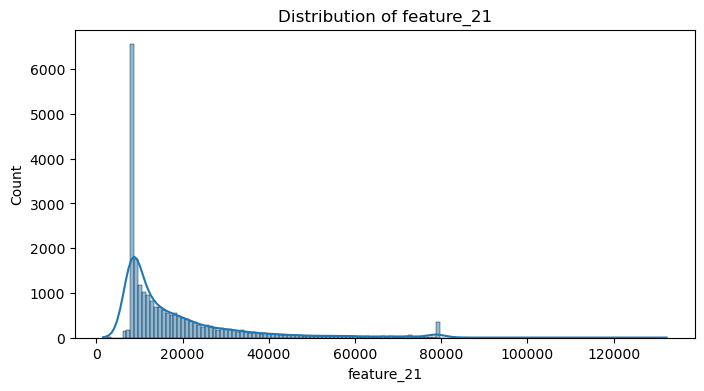

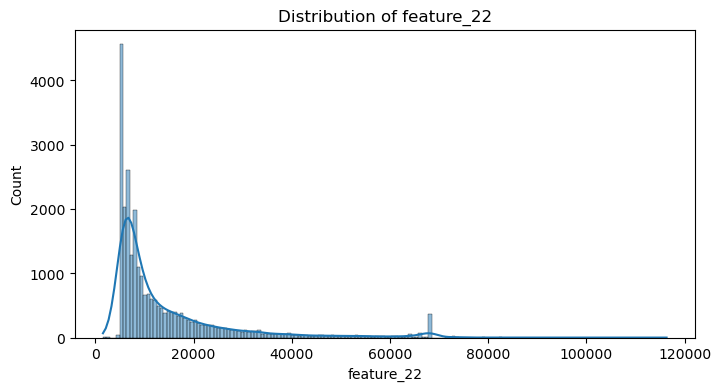

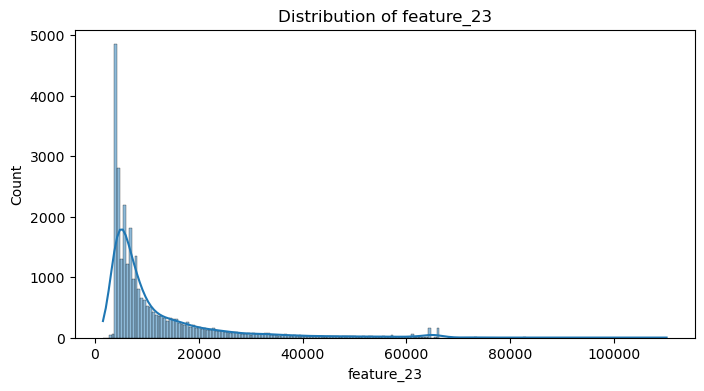

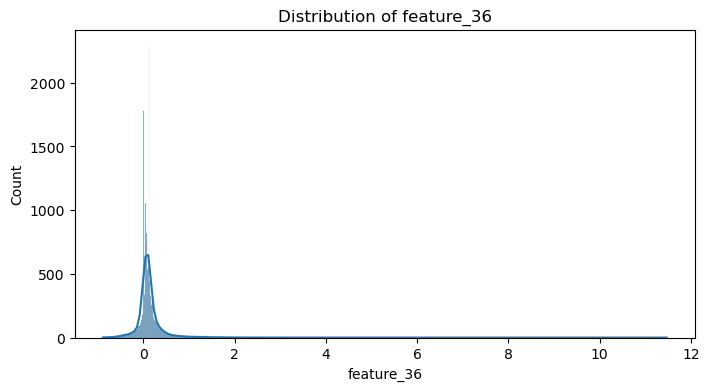

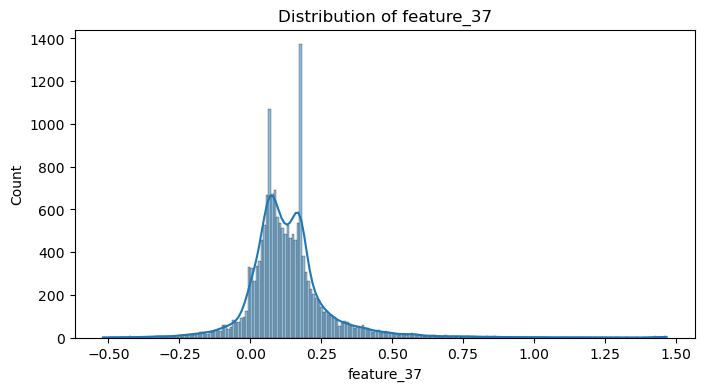

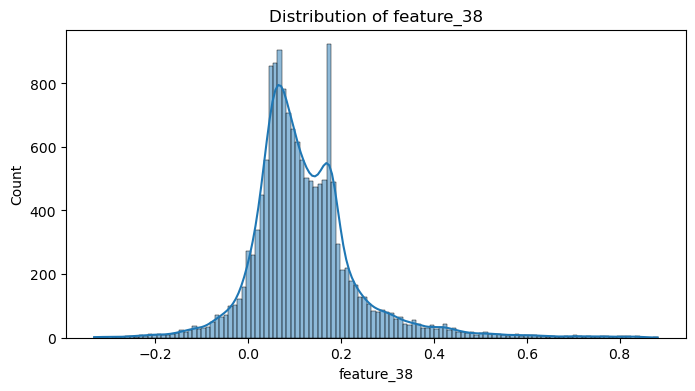

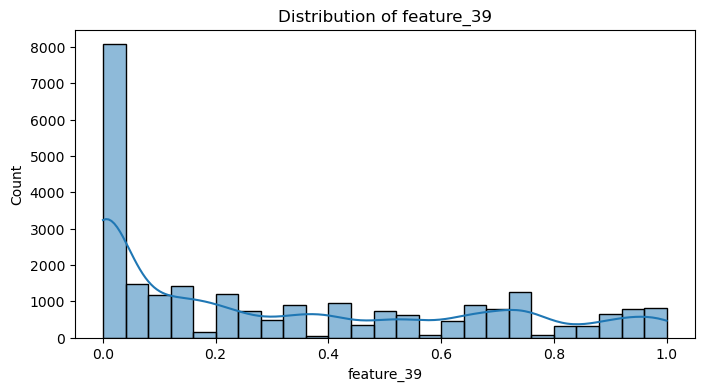

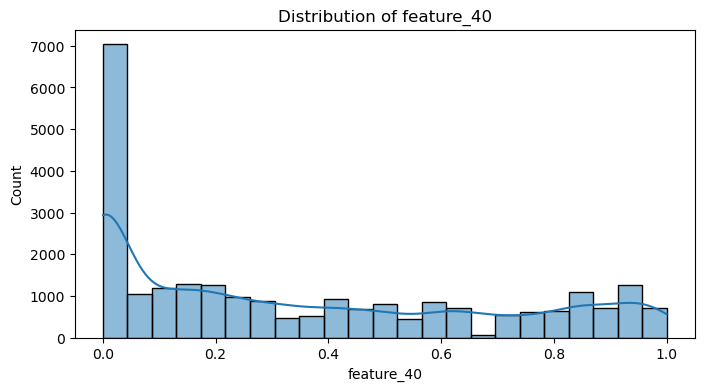

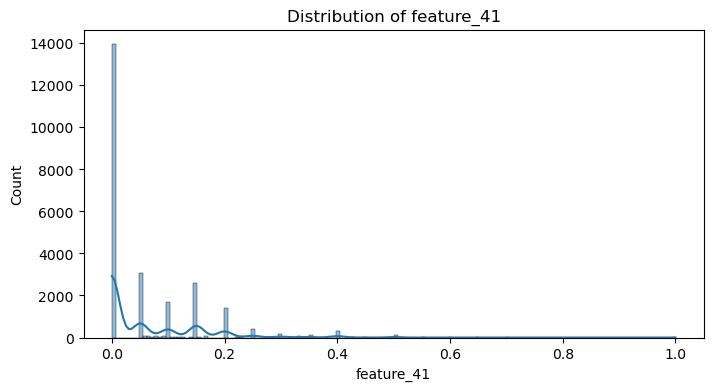

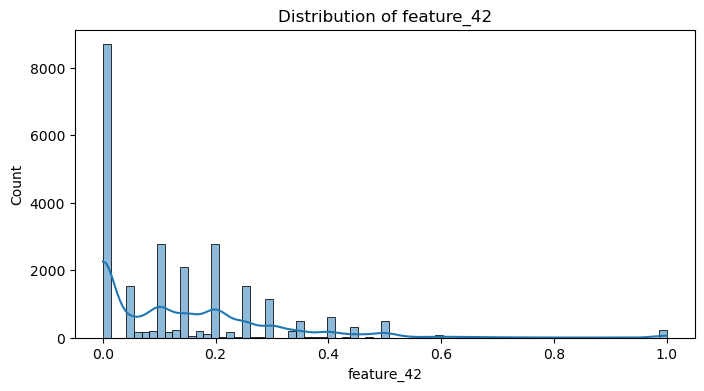

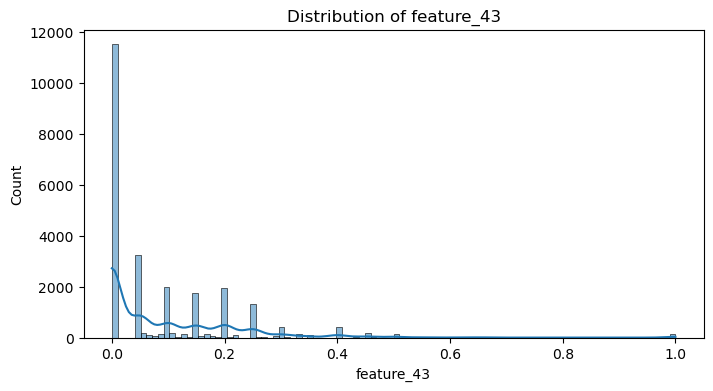

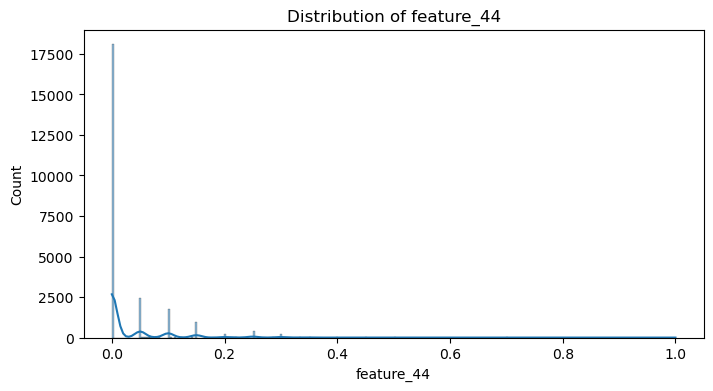

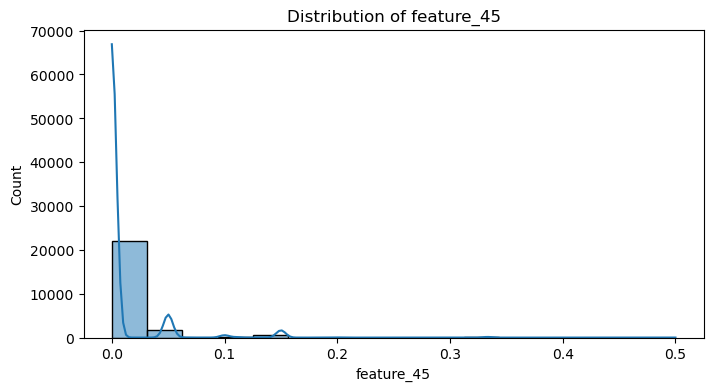

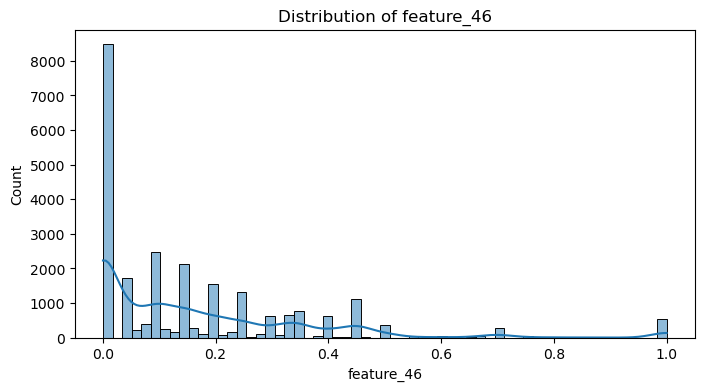

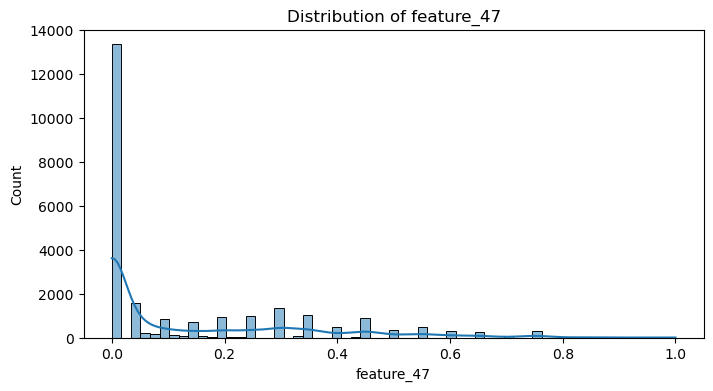

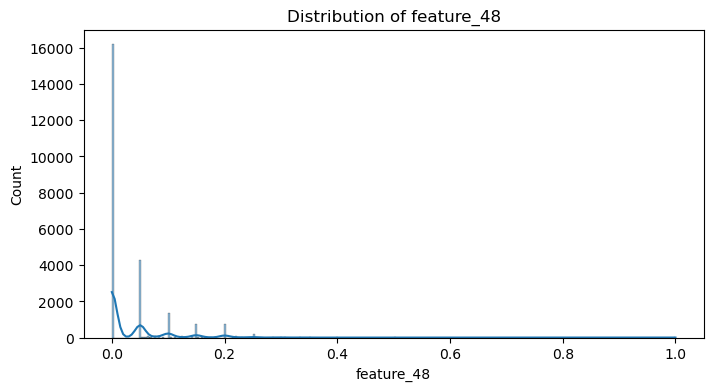

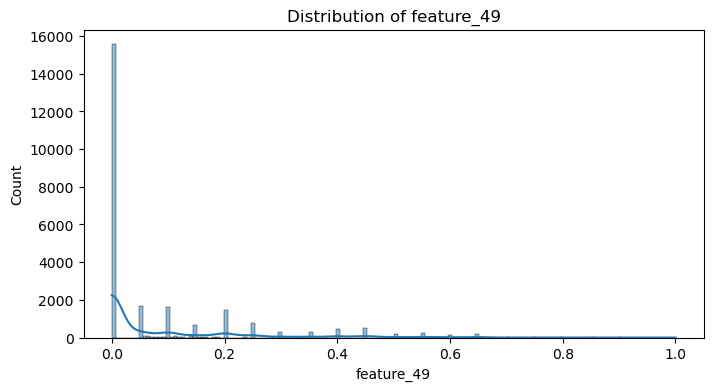

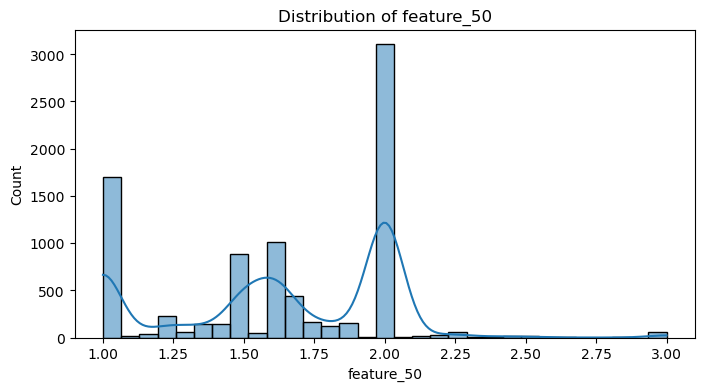

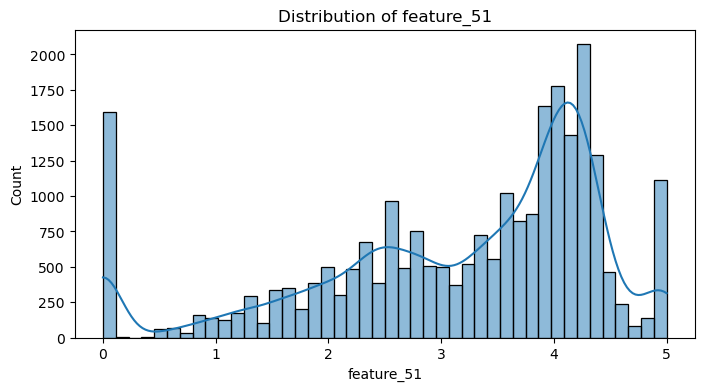

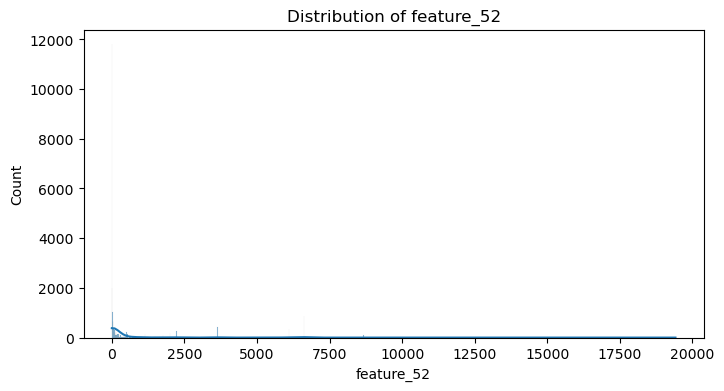

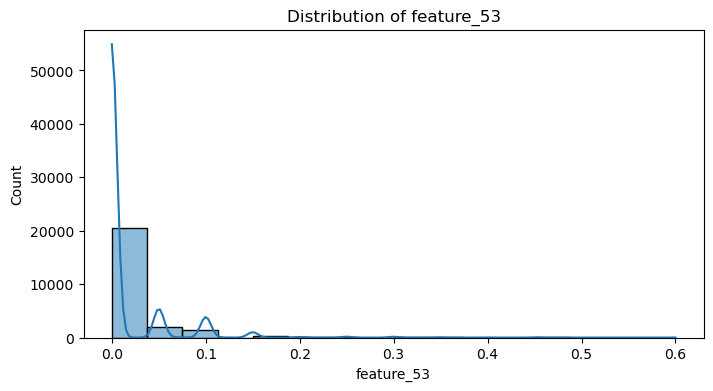

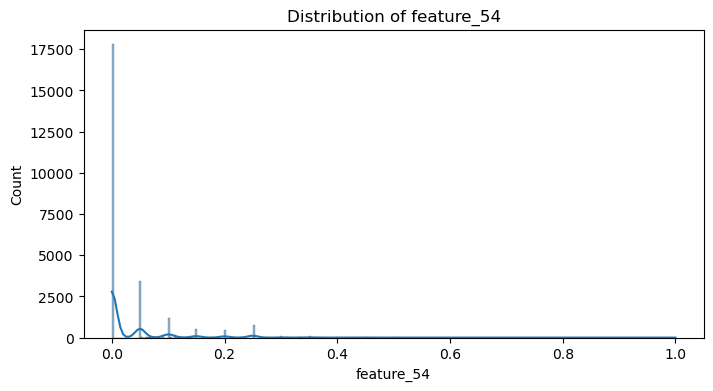

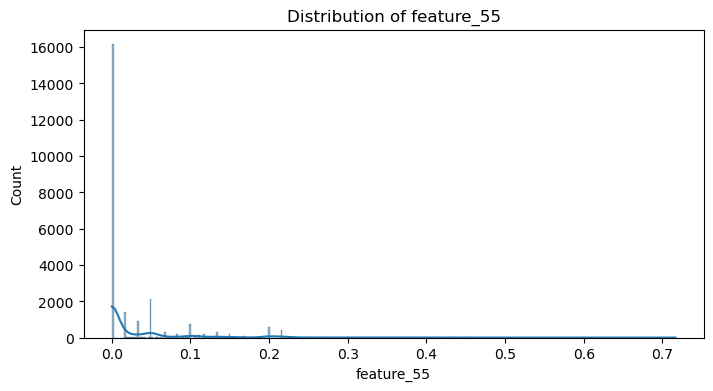

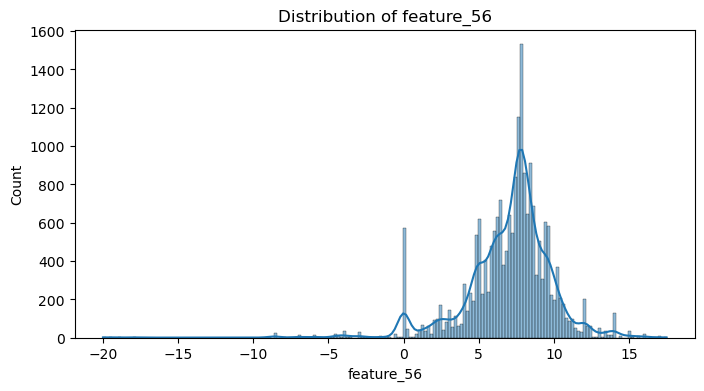

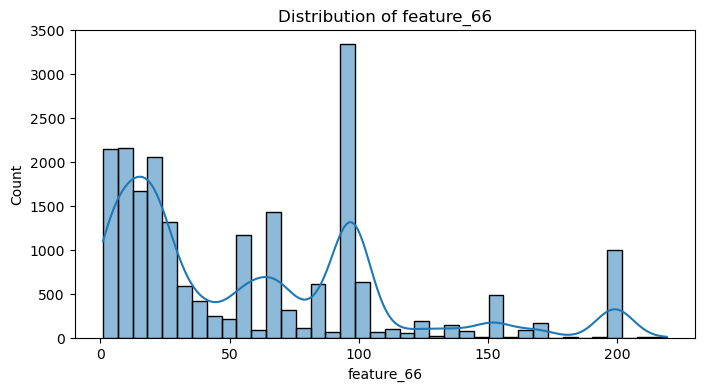

In [15]:
for col in ['feature_5', 'feature_6', 'feature_7', 'feature_10', 'feature_13',
       'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18',
       'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23',
       'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40',
       'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45',
       'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50',
       'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55',
       'feature_56', 'feature_66']:
    plt.figure(figsize=(8, 4))
    sns.histplot(Data[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In the graphs we can see that the basic distribution for each column that used to have NaN values are the same.

### Process Data for model construction 

Since the data is anonymized, contains a lot of features and the mayority of the features that contain missing values follow an exponential decrease distribution and come seem to show outliers in their distribution, several imputation and treatment methods will be used to later try on the models and compare results.

----------

In [3]:
# Library import ================================================================================

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from scipy.stats import zscore
from joblib import dump
import warnings
warnings.filterwarnings("ignore")

# Data load and general cleaning

Data = pd.read_csv('../Data/FPD.csv')

constant_cols = [col for col in Data.columns if Data[col].nunique() == 1]
Data = Data.drop(columns=constant_cols)

Data = Data.drop(columns=['ID'], errors='ignore')

for col in Data.columns:
    if Data[col].dtype == 'bool':
        Data[col] = Data[col].astype(int)

# saving function =================================================================================

def save_processed_data(data, path_suffix, scaler=None, pca=None, selector=None):
    save_dir = os.path.join('..', 'data', 'processed')
    os.makedirs(save_dir, exist_ok=True)

    data_path = os.path.join(save_dir, f'Data_{path_suffix}.pkl')
    data.to_pickle(data_path)
    
    if scaler:
        dump(scaler, os.path.join(save_dir, f'scaler_{path_suffix}.joblib'))
    if pca:
        dump(pca, os.path.join(save_dir, f'pca_{path_suffix}.joblib'))
    if selector:
        dump(selector, os.path.join(save_dir, f'selector_{path_suffix}.joblib'))

    print(f"Guardado: {path_suffix}")

# nitial partition ====================================================================

X_full = Data.drop(columns=['target'])
y_full = Data['target']

X_train_initial, X_test, y_train_initial, y_test = train_test_split(
    X_full, y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=42
)

train_initial = pd.concat([X_train_initial, y_train_initial], axis=1)
test_final = pd.concat([X_test, y_test], axis=1)

# Imputation Methods ====================================================================================

imputation_methods = {
    'drop_na': lambda df: df.dropna(),
    'mean_imputed': SimpleImputer(strategy='mean'),
    'median_imputed': SimpleImputer(strategy='median'),
    'knn_imputed': KNNImputer(n_neighbors=5),
    'iterative_imputed': IterativeImputer(random_state=42)
}

# Data engineering ===================================================================================

for name, imputer in imputation_methods.items():
    print(f"\n🔄 Procesando versión: {name}")

    
    if name == 'drop_na':
        train_imputed = imputer(train_initial)
    else:
        train_imputed = pd.DataFrame(
            imputer.fit_transform(train_initial), columns=train_initial.columns
        )

    
    X_train_imp = train_imputed.drop(columns=['target'])
    y_train_imp = train_imputed['target']

    
    train_imputed_df = pd.concat([X_train_imp, y_train_imp], axis=1)
    save_processed_data(train_imputed_df, name)

    
    try:
        # IQR Outlier Removal
        Q1 = X_train_imp.quantile(0.25)
        Q3 = X_train_imp.quantile(0.75)
        IQR = Q3 - Q1
        mask = ~((X_train_imp < (Q1 - 1.5 * IQR)) | (X_train_imp > (Q3 + 1.5 * IQR))).any(axis=1)
        X_iqr = X_train_imp[mask]
        y_iqr = y_train_imp.loc[X_iqr.index]
        train_iqr = pd.concat([X_iqr, y_iqr.reset_index(drop=True)], axis=1)
        save_processed_data(train_iqr, f"{name}_no_outliers_iqr")

        # Z-score Outlier Removal
        z_scores = X_train_imp.apply(zscore)
        mask_zscore = (np.abs(z_scores) <= 3).all(axis=1)
        X_zscore = X_train_imp[mask_zscore]
        y_zscore = y_train_imp.loc[X_zscore.index]
        train_zscore = pd.concat([X_zscore, y_zscore.reset_index(drop=True)], axis=1)
        save_processed_data(train_zscore, f"{name}_no_outliers_zscore")

    except Exception as e:
        print(f"Error en outlier removal para {name}: {e}")

    # Escaling
    scalers = {
        'standard': StandardScaler(),
        'minmax': MinMaxScaler()
    }

    for scale_name, scaler in scalers.items():
        X_scaled = scaler.fit_transform(X_train_imp)
        train_scaled = pd.concat([
            pd.DataFrame(X_scaled, columns=X_train_imp.columns),
            y_train_imp.reset_index(drop=True)
        ], axis=1)
        save_processed_data(train_scaled, f"{name}_{scale_name}", scaler=scaler)

    # Balance (SMOTE)
    smote = SMOTE(random_state=42)
    try:
        X_resampled, y_resampled = smote.fit_resample(X_train_imp, y_train_imp)
        train_balanced = pd.concat([pd.DataFrame(X_resampled, columns=X_train_imp.columns), y_resampled.reset_index(drop=True)], axis=1)
        save_processed_data(train_balanced, f"{name}_balanced_smote")
    except Exception as e:
        print(f"SMOTE falló para {name}: {e}")

    # Feature selection (SelectKBest)
    selector = SelectKBest(score_func=f_classif, k=50)
    X_selected = selector.fit_transform(X_train_imp, y_train_imp)
    train_selected = pd.concat([
        pd.DataFrame(X_selected),
        y_train_imp.reset_index(drop=True)
    ], axis=1)
    save_processed_data(train_selected, f"{name}_selectkbest", selector=selector)

    # PCA (95% variance)
    pca = PCA(n_components=0.95)
    X_pca = pca.fit_transform(X_train_imp)
    train_pca = pd.concat([
        pd.DataFrame(X_pca),
        y_train_imp.reset_index(drop=True)
    ], axis=1)
    save_processed_data(train_pca, f"{name}_pca", pca=pca)
    
# save ===========================================================================

save_processed_data(test_final, "test_final")
print("\n✅ Todos los datasets procesados y guardados.")




🔄 Procesando versión: drop_na
Guardado: drop_na
Guardado: drop_na_no_outliers_iqr
Guardado: drop_na_no_outliers_zscore
Guardado: drop_na_standard
Guardado: drop_na_minmax
Guardado: drop_na_balanced_smote
Guardado: drop_na_selectkbest
Guardado: drop_na_pca

🔄 Procesando versión: mean_imputed
Guardado: mean_imputed
Guardado: mean_imputed_no_outliers_iqr
Guardado: mean_imputed_no_outliers_zscore
Guardado: mean_imputed_standard
Guardado: mean_imputed_minmax
Guardado: mean_imputed_balanced_smote
Guardado: mean_imputed_selectkbest
Guardado: mean_imputed_pca

🔄 Procesando versión: median_imputed
Guardado: median_imputed
Guardado: median_imputed_no_outliers_iqr
Guardado: median_imputed_no_outliers_zscore
Guardado: median_imputed_standard
Guardado: median_imputed_minmax
Guardado: median_imputed_balanced_smote
Guardado: median_imputed_selectkbest
Guardado: median_imputed_pca

🔄 Procesando versión: knn_imputed
Guardado: knn_imputed
Guardado: knn_imputed_no_outliers_iqr
Guardado: knn_imputed_no_o

In [5]:
import yaml
from pathlib import Path

config_path = Path('..') / 'config' / 'pipelines.yaml'

with open(config_path, 'r', encoding='utf-8') as f:
    pipeline_config = yaml.safe_load(f)

print(pipeline_config)

{'versions': [{'name': 'knn_imputed_standard_smote', 'imputation': 'knn', 'scaling': 'standard', 'balancing': 'smote', 'feature_reduction': 'none'}, {'name': 'iterative_imputed_minmax_pca', 'imputation': 'iterative', 'scaling': 'minmax', 'balancing': 'none', 'feature_reduction': 'pca'}]}


In [ ]:
Save_path = os.path.join('..', 'data', 'processed', 'Data.pkl') 
os.makedirs(os.path.dirname(Save_path), exist_ok=True) 
Data.to_pickle(Save_path)

In [9]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from scipy.stats import zscore
from joblib import dump

def save_processed_data(data, path_suffix):
    save_dir = os.path.join('..', 'data', 'processed')
    os.makedirs(save_dir, exist_ok=True)
    data_path = os.path.join(save_dir, f'Data_{path_suffix}.pkl')
    data.to_pickle(data_path)
    print(f"Saved: {path_suffix}")

# Load raw data
Data = pd.read_csv('../Data/FPD.csv')

# Drop constant columns and ID
constant_cols = [col for col in Data.columns if Data[col].nunique() == 1]
Data = Data.drop(columns=constant_cols)
Data = Data.drop(columns=['ID'], errors='ignore')

# Convert bool to int
for col in Data.columns:
    if Data[col].dtype == 'bool':
        Data[col] = Data[col].astype(int)

# Train/test split
X_full = Data.drop(columns=['target'])
y_full = Data['target']
X_train_initial, X_test, y_train_initial, y_test = train_test_split(
    X_full, y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=42
)

train_initial = pd.concat([X_train_initial, y_train_initial], axis=1)
test_final = pd.concat([X_test, y_test], axis=1)

# Save test set
save_processed_data(test_final, "test_final")

# Define imputation methods
imputation_methods = {
    'drop_na': lambda df: df.dropna(),
    'mean_imputed': SimpleImputer(strategy='mean'),
    'median_imputed': SimpleImputer(strategy='median'),
    'knn_imputed': KNNImputer(n_neighbors=5),
    'iterative_imputed': IterativeImputer(random_state=42)
}

# Generate processed datasets
for name, imputer in imputation_methods.items():
    print(f"\n🔄 Processing version: {name}")
    
    if name == 'drop_na':
        train_imputed = imputer(train_initial)
    else:
        train_imputed = pd.DataFrame(
            imputer.fit_transform(train_initial), columns=train_initial.columns
        )

    # Save imputed training data
    save_processed_data(train_imputed, name)

Saved: test_final

🔄 Processing version: drop_na
Saved: drop_na

🔄 Processing version: mean_imputed
Saved: mean_imputed

🔄 Processing version: median_imputed
Saved: median_imputed

🔄 Processing version: knn_imputed
Saved: knn_imputed

🔄 Processing version: iterative_imputed
Saved: iterative_imputed


C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
